In [1]:
import os
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [2]:
# Paths
base_dir = os.getcwd()
train_txt_path = os.path.join(base_dir, "balinese_transliteration_train.txt")
train_img_dir = os.path.join(base_dir, "balinese_word_train")
test_txt_path = os.path.join(base_dir, "balinese_transliteration_test.txt")
test_img_dir = os.path.join(base_dir, "balinese_word_test")

# Helper Function to Read Data
def read_data(txt_path, img_dir):
    filenames, labels = [], []
    with open(txt_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line:
                parts = line.split(";")
                if len(parts) == 2:
                    filenames.append(parts[0])
                    labels.append(parts[1])
                else:
                    print(f"Skipping malformed line: {line}")
    data = pd.DataFrame({"filename": filenames, "label": labels})
    data["label_length"] = data["label"].apply(len)
    return data, img_dir

# Load Train and Test Data
train_data, train_img_dir = read_data(train_txt_path, train_img_dir)
test_data, test_img_dir = read_data(test_txt_path, test_img_dir)

# Split Train Data into Train/Validation (9:1 Split)
train_data, val_data = train_test_split(train_data, test_size=0.1, random_state=42)

print(f"Train Samples: {len(train_data)}, Validation Samples: {len(val_data)}, Test Samples: {len(test_data)}")


Train Samples: 13519, Validation Samples: 1503, Test Samples: 10475


In [3]:
# Dataset Class
class BalineseDataset(Dataset):
    def __init__(self, data, img_dir, transform=None):
        self.data = data.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.loc[idx, "filename"]
        label_length = self.data.loc[idx, "label_length"]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label_length

# Transform
transform = transforms.Compose([
    transforms.Resize((64, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create Datasets and DataLoaders
batch_size = 32
train_dataset = BalineseDataset(train_data, train_img_dir, transform=transform)
val_dataset = BalineseDataset(val_data, train_img_dir, transform=transform)
test_dataset = BalineseDataset(test_data, test_img_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [4]:
# Length Prediction Model
class LengthPredictor(nn.Module):
    def __init__(self, encoder_dim=512):
        super(LengthPredictor, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])  # Remove FC Layer
        self.fc = nn.Linear(encoder_dim, 1)  # Predict Length as a Regression Task

    def forward(self, images):
        features = self.encoder(images).view(images.size(0), -1)
        length_logits = self.fc(features)
        return length_logits

model = LengthPredictor().to(device)
criterion = nn.MSELoss()  # Using Mean Squared Error Loss for Regression
optimizer = optim.Adam(model.parameters(), lr=1e-4)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
# Train Function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, lengths in train_loader:
            images = images.to(device)
            lengths = lengths.to(device).float().unsqueeze(1)  # Shape [batch_size, 1]

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, lengths)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        val_loss = evaluate_model(model, val_loader, criterion)
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

# Evaluate Function
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, lengths in data_loader:
            images = images.to(device)
            lengths = lengths.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, lengths)
            total_loss += loss.item()
    return total_loss / len(data_loader)

train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)


Epoch 1/5 - Train Loss: 2.3632, Val Loss: 1.1994
Epoch 2/5 - Train Loss: 0.9412, Val Loss: 1.0387
Epoch 3/5 - Train Loss: 0.5685, Val Loss: 1.0016
Epoch 4/5 - Train Loss: 0.3937, Val Loss: 0.9421
Epoch 5/5 - Train Loss: 0.2863, Val Loss: 0.9153


In [6]:
# Evaluate on Test Set
def test_model(model, test_loader):
    model.eval()
    predictions, ground_truths = [], []
    with torch.no_grad():
        for images, lengths in test_loader:
            images = images.to(device)
            lengths = lengths.to(device).float()
            outputs = model(images).squeeze(1).cpu().numpy()
            predictions.extend(outputs)
            ground_truths.extend(lengths.cpu().numpy())
    return predictions, ground_truths

predictions, ground_truths = test_model(model, test_loader)


Mean Absolute Error (MAE) on Test Set: 0.68


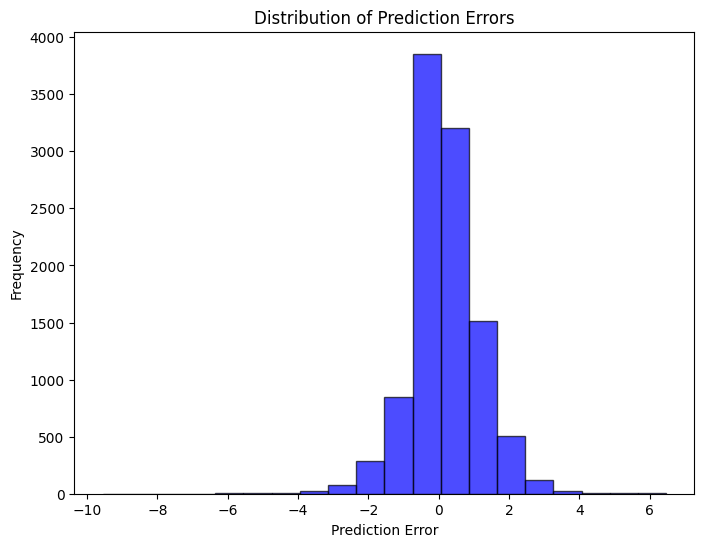

In [10]:
# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(np.array(predictions) - np.array(ground_truths)))
print(f"Mean Absolute Error (MAE) on Test Set: {mae:.2f}")

# # Scatter Plot of Predictions vs Ground Truth
# plt.figure(figsize=(8, 6))
# plt.scatter(ground_truths, predictions, alpha=0.6)
# plt.plot([min(ground_truths), max(ground_truths)], [min(ground_truths), max(ground_truths)], color='red', linestyle='--')
# plt.title("Length Prediction: Ground Truth vs Predictions")
# plt.xlabel("Ground Truth")
# plt.ylabel("Predicted")
# plt.show()

# Histogram of Prediction Errors
errors = np.array(predictions) - np.array(ground_truths)
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()
